# Ngày 5 (mở rộng, phần 4) — Calibration: Xác suất có "đáng tin" không?

Ở phần "Nếu làm lại" của README, mình từng đoán: *"ngưỡng cuối chỉ 0.092 — dấu hiệu xác suất
CatBoost đang lệch thấp, nên thử calibration"*. Đây là lúc kiểm tra xem phỏng đoán đó có đúng
không — và spoiler: kết quả sẽ khiến mình phải **sửa lại chính nhận định của mình**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score, precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv("../data/processed/attrition_encoded.csv")
X = df.drop(columns=['Attrition']); y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = joblib.load("../models/scaler.pkl")
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
y_test_arr = y_test.values

model = joblib.load("../models/final_model.pkl")
proba_uncal = model.predict_proba(X_test_scaled)[:, 1]


## 1. Reliability Diagram — mô hình hiện tại đã calibrate tốt đến đâu?

Một mô hình calibrate hoàn hảo: trong số các ca được dự đoán "20% khả năng nghỉ", đúng 20%
trong số đó thực sự nghỉ. Đường chéo = calibrate hoàn hảo.

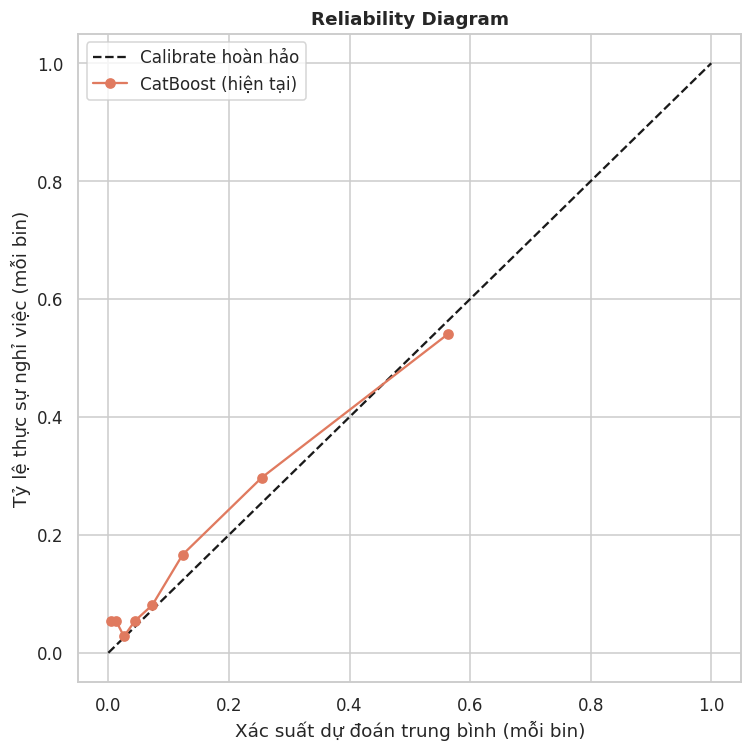

Brier score (0 = hoàn hảo): 0.1002

Phân phối xác suất dự đoán: mean=0.138, median=0.057
% dự đoán < 0.1: 64.6%  |  % dự đoán > 0.5: 6.1%


In [2]:
frac_pos, mean_pred = calibration_curve(y_test_arr, proba_uncal, n_bins=8, strategy='quantile')

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Calibrate hoàn hảo')
plt.plot(mean_pred, frac_pos, 'o-', color='#e07a5f', label='CatBoost (hiện tại)')
plt.xlabel("Xác suất dự đoán trung bình (mỗi bin)")
plt.ylabel("Tỷ lệ thực sự nghỉ việc (mỗi bin)")
plt.title("Reliability Diagram")
plt.legend()
plt.tight_layout()
plt.savefig("../images/25_reliability_diagram.png", bbox_inches='tight')
plt.show()

print(f"Brier score (0 = hoàn hảo): {brier_score_loss(y_test_arr, proba_uncal):.4f}")
print(f"\nPhân phối xác suất dự đoán: mean={proba_uncal.mean():.3f}, median={np.median(proba_uncal):.3f}")
print(f"% dự đoán < 0.1: {(proba_uncal<0.1).mean()*100:.1f}%  |  % dự đoán > 0.5: {(proba_uncal>0.5).mean()*100:.1f}%")


Các điểm bám khá sát đường chéo — không có lệch hệ thống lớn. Nhưng phân phối xác suất
dồn rất nhiều về phía thấp (64.6% dự đoán dưới 10%, median chỉ 5.7%) khiến trực giác "ngưỡng
0.092 nghe rất thấp, chắc model có vấn đề" — đây chính là giả thuyết cần kiểm tra.

## 2. Thử calibrate lại bằng Platt Scaling (`CalibratedClassifierCV`)

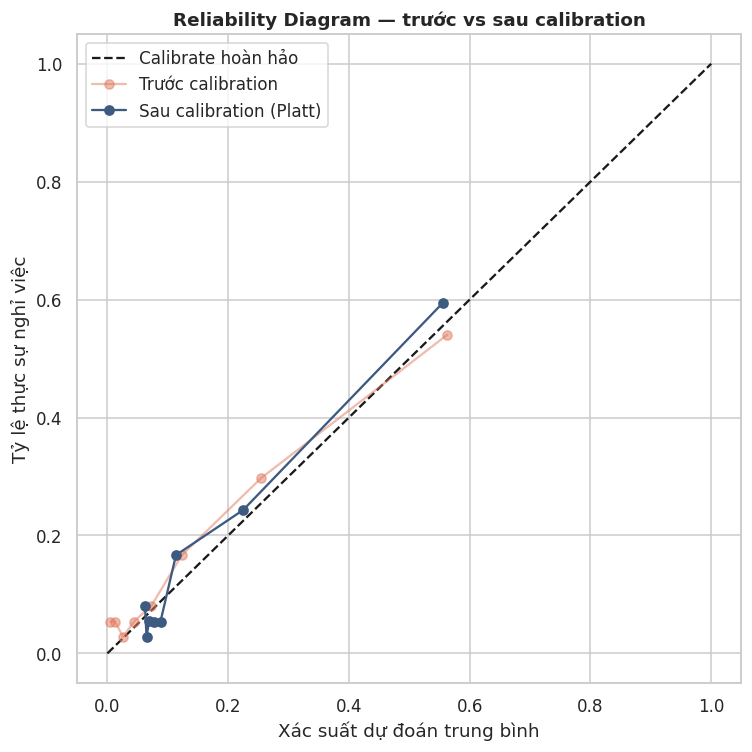

In [3]:
base_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', CatBoostClassifier(random_state=42, verbose=False, allow_writing_files=False,
                                learning_rate=0.03, l2_leaf_reg=1, iterations=400, depth=6)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
calibrated = CalibratedClassifierCV(base_pipe, method='sigmoid', cv=cv)
calibrated.fit(X_train_scaled, y_train)
proba_cal = calibrated.predict_proba(X_test_scaled)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test_arr, proba_cal, n_bins=8, strategy='quantile')

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Calibrate hoàn hảo')
plt.plot(mean_pred, frac_pos, 'o-', color='#e07a5f', alpha=0.5, label='Trước calibration')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', color='#3d5a80', label='Sau calibration (Platt)')
plt.xlabel("Xác suất dự đoán trung bình"); plt.ylabel("Tỷ lệ thực sự nghỉ việc")
plt.title("Reliability Diagram — trước vs sau calibration")
plt.legend()
plt.tight_layout()
plt.savefig("../images/26_calibration_before_after.png", bbox_inches='tight')
plt.show()


In [4]:
comparison = pd.DataFrame({
    'Trước calibration': [
        brier_score_loss(y_test_arr, proba_uncal),
        roc_auc_score(y_test_arr, proba_uncal),
        average_precision_score(y_test_arr, proba_uncal),
        proba_uncal.mean(),
    ],
    'Sau calibration': [
        brier_score_loss(y_test_arr, proba_cal),
        roc_auc_score(y_test_arr, proba_cal),
        average_precision_score(y_test_arr, proba_cal),
        proba_cal.mean(),
    ],
}, index=['Brier score (thấp hơn=tốt hơn)', 'ROC-AUC', 'PR-AUC', 'Xác suất dự đoán trung bình'])
comparison.round(4)


,Trước calibration,Sau calibration
Brier score (thấp hơn=tốt hơn),0.1002,0.0984
ROC-AUC,0.8012,0.8003
PR-AUC,0.5720,0.5821
Xác suất dự đoán trung bình,0.1382,0.1573


In [5]:
prec_c, rec_c, thr_c = precision_recall_curve(y_test_arr, proba_cal)
valid = np.where(rec_c[:-1] >= 0.80)[0]
new_threshold = thr_c[valid[-1]]
print(f"Ngưỡng để đạt Recall>=0.80:")
print(f"  Trước calibration: 0.092")
print(f"  Sau calibration:   {new_threshold:.3f}")
print(f"  -> Gần như KHÔNG đổi, dù xác suất đã được calibrate lại")


Ngưỡng để đạt Recall>=0.80:
  Trước calibration: 0.092
  Sau calibration:   0.094
  -> Gần như KHÔNG đổi, dù xác suất đã được calibrate lại


## 3. Kết luận — sửa lại chính giả thuyết ban đầu của mình

**Giả thuyết cũ (trong README, phần "Nếu làm lại"): xác suất bị lệch, cần calibration.**
Sau khi kiểm tra: **giả thuyết đó không chính xác.** Brier score gần như không đổi
(0.1002 → 0.0984), ROC-AUC/PR-AUC gần như không đổi, và quan trọng nhất — **ngưỡng để đạt
Recall≥0.80 gần như y nguyên** (0.092 → 0.094) dù đã calibrate lại bằng Platt scaling.

**Lý do thật:** với một mô hình calibrate đúng, xác suất dự đoán trung bình trên toàn bộ
tập dữ liệu *phải* hội tụ về đúng tỷ lệ nền (base rate) — ở đây là ~16%. Threshold thấp
(0.092) không phải dấu hiệu model "hỏng" hay "lệch" — nó là hệ quả **toán học tất yếu** của
việc yêu cầu Recall cao (0.80) trên một bài toán có base rate thấp (16%). Calibration là
đúng hướng để nghĩ tới, nhưng trong trường hợp cụ thể này, nó không phải nguyên nhân của
threshold thấp — và giờ mình biết chắc điều đó bằng thực nghiệm, không phải suy đoán.

Đây là một bài học độc lập với mọi kết quả kỹ thuật khác: **một giả thuyết nghe hợp lý vẫn
cần được kiểm tra bằng số liệu trước khi ghi vào README như một khuyến nghị chắc chắn.**
